In [2]:
%load_ext autoreload
%autoreload 2
import os
import sys
modul_path = "/home/jona/Schreibtisch/Studium/Semester4/Projektarbeit"
if modul_path not in sys.path:
    sys.path.append(modul_path)
import stochastinetics
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm

### Testing the Alfonsi Algorithm

1. Expectation value and stationary probabilities of the birth death process:

$$ \xrightarrow{k_1} A \xrightarrow{k_2} $$

$$ \langle A(t) \rangle = \frac{k_1}{k_2} + \left (A(0)- \frac{k_1}{k_2}\right)  e^{-k_2*t} $$

\begin{align*}
\pi_0 &= \frac{1}{1+ \sum_{k=1}^{\infty}\prod_{i=1}^{k} \frac{k_1}{i*k_2}} = \frac{1}{1 + e^{\frac{k_1}{k_2}}} \\
\Rightarrow \pi_k &=  \pi_0 \prod_{i=1}^{k} \frac{k_1}{i*k_2}, k = 1,2,..., \infty \\
&= \left(\frac{k_1}{k_2}\right)^k \frac{1}{k!}e^{-\frac{k_1}{k_2}}
\end{align*}




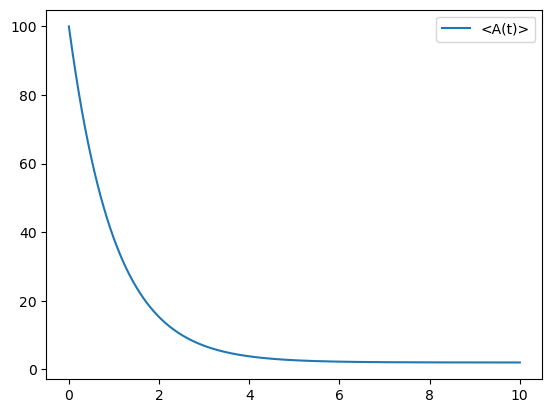

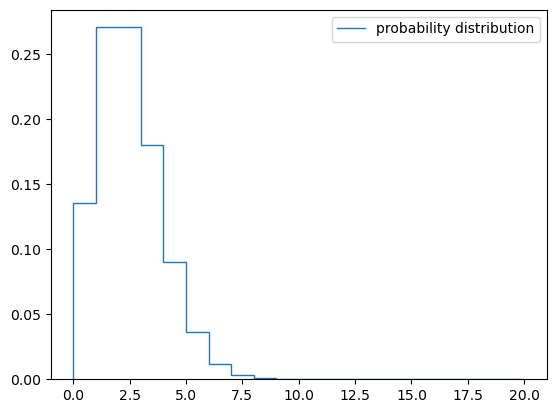

In [3]:
# analytical solution only
k1 = 2.0
k2 = 1.0
A0 = np.array([100])
t_start = 0
t_end = 10
n = 1000
t = np.linspace(t_start,t_end,n)

pi_0 = np.exp(-k1/k2)
pi = np.array([(k1/k2)**k * 1/math.factorial(k) * np.exp(-k1/k2) for k in range(1,20)])
pi = np.insert(pi,0,pi_0)

plt.plot(t,k1/k2 + (A0-k1/k2)*np.exp(-k2*t),label="<A(t)>")
plt.legend()
plt.show()

plt.stairs(pi,edges=np.arange(21), label="probability distribution")
plt.legend()
plt.show()

100%|██████████| 1000/1000 [01:36<00:00, 10.33it/s]


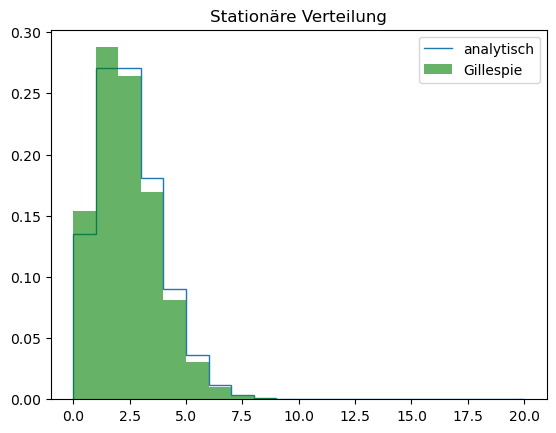

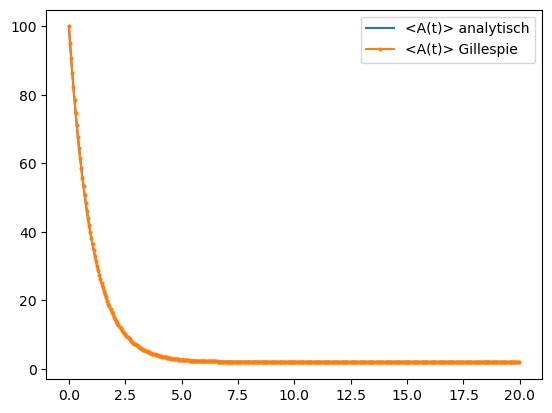

In [ ]:
# Alfonsi algorithm -- Comparison with analytical solution
# Title is wrong --> should be alfonsi not gillespie

k1 = 2.0
k2 = 1.0
c = np.array([k1, k2])
A0 = 100.0 
t_start = 0
t_end = 20
S = np.array([[1, -1]])
S_ed = np.array([[0, 1]])
threshold=10
n = 1000
t = np.linspace(t_start,t_end,n)
t_end = 20
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2])

pi_0 = np.exp(-k1/k2)
pi = np.array([(k1/k2)**k * 1/math.factorial(k) * np.exp(-k1/k2) for k in range(1,20)])
pi = np.insert(pi,0,pi_0)


times,x = [],[]
for i in tqdm(range(1000)):
    ti,xi = stochastinetics.hybrid(S,S_ed,c,t_start,[A0],t_end,threshold)
    #ti,xi = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t_start,[A0],t_end,delta_t,Delta_t,boundaries)
    #ti, xi = stochastinetics.SSA(S_test,S_ed_test,c,t_start,A0,t_end)
    times.append(ti)
    x.append(xi)

"""1.Stationäre Verteilung:"""
z = [] 
n_sims = len(times)

for ti in np.arange(10, 20, 0.05): 
    states, probs = stochastinetics.get_distribution(times, x, ti,type="Hybrid") 
    for j, state in enumerate(states): 
        number = int(round(probs[j] * n_sims)) 
        val = state[0] if isinstance(state, np.ndarray) and state.ndim > 0 else state 
        z.extend([val] * number)

plt.stairs(pi, edges=np.arange(21), label="analytisch")
plt.hist(z, bins=np.arange(21), density=True, alpha=0.6, color='g', label="Gillespie")
plt.legend()
plt.title("Stationäre Verteilung")
plt.show()


"""2.Erwartungswerte:"""
erwartungs = [] 
for ti in np.arange(0, 20, 0.05): 
    states, probs = stochastinetics.get_distribution(times, x, ti,type="Hybrid") 
    erwartungs.append(np.sum(states.flatten() * probs))

plt.plot(t, k1/k2 + (A0-k1/k2)*np.exp(-k2*t), label="<A(t)> analytisch")
plt.plot(np.arange(0, 20, 0.05), erwartungs, "o-", markersize=2, label="<A(t)> Gillespie")
plt.legend()
plt.show()

2. Expectation values and Probabilities of the Dimerisation process:

$$2\cdot A \xrightarrow{k_1} B, \ B \xrightarrow{k_2} 2\cdot A$$

<center>The quantity:</center>

$$M = n_A + 2*n_B$$
<center>is constant in our system which results in a finite number of possible system states:</center>

$$(M,0), \ (M-2,1), ... ,\left(0,\lfloor \frac{M}{2}\rfloor \right)$$
<center>Therefore the CME:</center>

$$\frac{dP(t)}{dt} = A \cdot P(t)$$

$$A = \begin{pmatrix}
-k_1 \frac{M(M-1)}{2} & k_2 & 0 & \cdots & 0 \\
k_1 \frac{M(M-1)}{2} & -\left(k_1 \frac{(M-2)(M-3)}{2} + k_2\right) & 2k_2 & \cdots & 0 \\
0 & k_1 \frac{(M-2)(M-3)}{2} & -\left(k_1 \frac{(M-4)(M-5)}{2} + 2k_2\right) & \cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & -\lfloor \frac{M}{2} \rfloor \cdot k_2
\end{pmatrix}$$

<center> is solvable by: </center>

$$P(t) = \sum_{i=0}^n c_i v_i e^{\lambda_i t}$$
with eigenvektors $v_i$ and eigenvalues $\lambda_i$ of A.

The expecation values e.g. $ \langle A(t) \rangle$ can therefore be determined as well:

$$ \langle A(t) \rangle = \sum_{k=0}^{M-1} (n_{A0} + 2*(n_{B0}-k))*P_k(t)$$

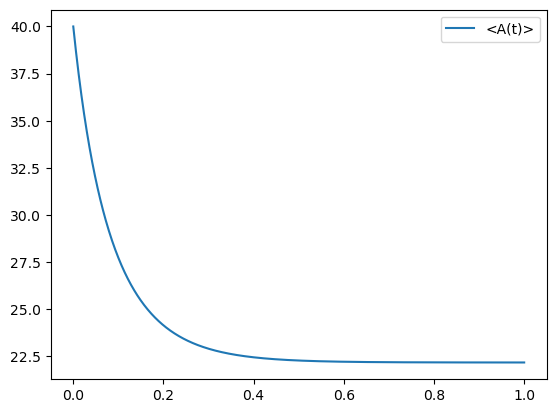

In [ ]:
# analytical solution only

def construct_matrix(A0,B0,k1,k2):
    M = A0 + 2*B0
    n = int(np.floor(M/2) +1)
    haupt_diag = [-k1*(M-2*i)*(M-2*i-1)/2 - (i)*k2 for i in range(n)]
    obere_diag = [(i+1)*k2 for i in range(n-1)]
    untere_diag = [k1*(M-2*i)*(M-2*i-1)/2 for i in range(n-1)]
    M= (np.diag(haupt_diag, k=0) + np.diag(obere_diag, k=1) + np.diag(untere_diag, k=-1))
    return M

# Definiere Vol_Scale um wirklich nur die volumenunabhänigige Reaktionskonstante
# zu ändern --> nur k1_V skaliert invers mit V --> um ratio zwischen den beiden
# volumenunabhängigen zu ändern muss V mit berücksichtigt werden
Vol_Scale = 10 
A0 = 4 * Vol_Scale
B0 = 4 * Vol_Scale
k1 = 2.0 / Vol_Scale
k2 = 1
t_start, t_end, m = 0, 1, 1000

K = A0 + 2*B0
P0 = np.zeros(int(np.floor(K/2))+1)
P0[B0] = 1
M = construct_matrix(A0,B0,k1,k2)
eigenwerte, eigenvektoren = np.linalg.eig(M)
c2 = np.linalg.solve(eigenvektoren, P0)
t = np.linspace(t_start,t_end,m)

P = eigenvektoren @ (c2[:,None]*np.exp(eigenwerte[:,None]*t))
P = P.real
P = np.maximum(P,0)

states_A = np.array([K-2*i for i in range(len(P0))])
A_exp = P.T@states_A

plt.plot(t,A_exp,label="<A(t)>")
plt.legend()
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:09<00:00, 108.84it/s]


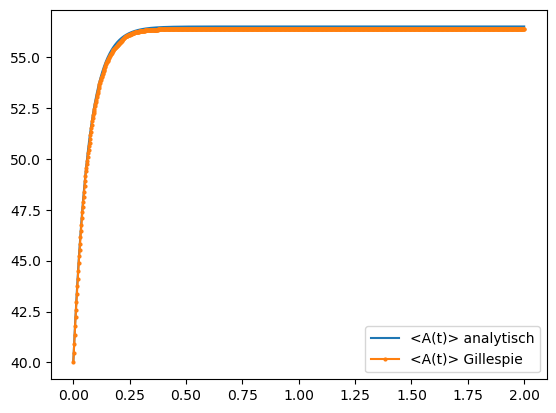

In [ ]:
# Alfonsi algorithm -- Comparision analytical solution
# Title is wrong again --> should be alfonsi not gillespie

Vol_Scale = 10 
A0 = 4 * Vol_Scale
B0 = 4 * Vol_Scale
k1 = 1.0 / Vol_Scale
k2 = 5.0
t_start, t_end, m = 0, 2, 1000
S = np.array([[-2,2],[1,-1]])
S_ed =np.array([[2,0],[0,1]])
threshold = 30
t = np.linspace(t_start,t_end,m)
c = np.array([k1,k2])
Delta_t = 10**(-3)
delta_t = 10**(-2)
I1 = 25.0
I2 = 35.0
boundaries = np.array([I1,I2,I1,I2])

K = A0 + 2*B0
P0 = np.zeros(int(np.floor(K/2))+1)

times,x = [],[]
for i in tqdm(range(1000)):
    #ti,xi = stochastinetics.hybrid_duncan_ssa(S,S_ed,c,t_start,[A0,B0],t_end,delta_t,Delta_t,boundaries)
    #ti,xi = stochastinetics.SSA(S,S_ed,c,t_start,[A0,B0],t_end)
    ti,xi = stochastinetics.hybrid(S,S_ed,c,t_start,[A0,B0],t_end,threshold)
    times.append(ti)
    x.append(xi)

erwartungs = [] 
for ti in t: 
    states, probs = stochastinetics.get_distribution(times, x, ti) 
    erwartungs.append(np.sum(states[:,0] * probs))

P0[B0] = 1
M = construct_matrix(A0,B0,k1,k2)
eigenwerte, eigenvektoren = np.linalg.eig(M)
c2 = np.linalg.solve(eigenvektoren, P0)
P = eigenvektoren @ (c2[:,None]*np.exp(eigenwerte[:,None]*t))
P = P.real
P = np.maximum(P,0)
states_A = np.array([K-2*i for i in range(len(P0))])
A_exp = P.T@states_A


plt.plot(t, A_exp, label="<A(t)> analytisch")
plt.plot(t, erwartungs, "o-", markersize=2, label="<A(t)> Gillespie")
plt.legend()
plt.show()